# Assignment 1 - AcnEmphathize Dataset

**Course:** Natural Language Processing

**Group:** 12

    Guilherme Oliveira: 202204987
    Magda Costa: 202207036

---

# Index  <a name = "index"></a>
1. [Exploratory Data Analysis](#eda)
    - [Dataset Overview](#do)
    - [Dataset Structure](#dt)
    - [Dataset Summary](#ds)
    - [Loading the Dataset](ld)
    - [Dataset Structure](#d_structure)
    - [Dataset Size](#d_size)
    - [Class Distribution](#cd)
    - [Conversation Analysis](#ca)
    - [User Activity](#ua)
    - [Text Length Analysis](#tla)
    - [Post Length by Class](#plc)
    - [Language patterns](#lp)
        - [Tokenization of Posts](#tp)
        - [Vocabulary Size](#vs)
        - [Most Frequent Words](#mfw)
        - [Vocabulary Differences Between Classes](vdbw)
        - [Bigram Analysis](#ba)
        - [Topic Modeling](#tm)
2. [EDA Conclusion](#eda_c)
3.  [References](#r)

---

# Exploratory Data Analysis <a name = "eda"></a>

This notebook provides a detailed exploratory analysis of the **AcnEmpathize dataset**, which contains annotated posts from an online acne support forum.

The goal of this analysis is to:

• Understand the structure of the dataset    
• Explore linguistic patterns related to empathy  
• Identify potential challenges for modeling  



## Dataset Overview <a name = "do"></a>

The AcnEmpathize dataset contains posts from discussions on acne.org, specifically from the forum:

**"Emotional and Psychological Effects of Acne"**

Users in this forum discuss the emotional impact of acne and provide support to each other.

Each post is annotated with a binary label:

- 0 → No Empathy  
- 1 → Empathy

Empathy in this dataset is defined as expressions that:

• show compassion or concern  
• demonstrate understanding of another person's feelings  
• explore the emotional experience of the other user

The dataset contains over **12,000 posts across ~1,700 conversations**.

##  Dataset Structure <a name = "dt"></a>

The AcnEmpathize dataset is composed of forum-based conversations collected from an online acne support community. Rather than consisting of isolated texts, the dataset is organized into conversation threads, where each thread contains multiple posts.

- Each conversation begins with an initial post, typically written by a user seeking advice or emotional support. Other users then contribute through replies or quotes, forming a discussion thread. Replies are direct responses to previous posts, while quotes include excerpts of earlier messages along with additional commentary.

- After preprocessing and filtering, the dataset contains approximately 1,730 conversations and 12,212 posts. These posts are distributed across three main types: initial posts, replies, and quotes. The number of posts per conversation varies significantly, ranging from single-post conversations to threads containing up to 23 posts.

- Each post is treated as an individual instance for the classification task and is labeled as either containing empathy or not. However, it is important to note that posts are not independent in nature, as they are part of a broader conversational context.

## Dataset Summary <a name = "dt"></a>

| Component           | Count  |
|--------------------|--------|
| Conversations      | ~1,730 |
| Total posts        | ~12,212 |
| Initial posts      | 1,730 |
| Replies            | 7,891 |
| Quotes             | 2,591 |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import re
import spacy
import string
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from utils.log_odds import compute_log_odds, get_top_k, plot_log_odds

## 1. Loading the Dataset <a name = "ld"></a>

We start by loading the dataset and inspecting its structure.

In [2]:
df = pd.read_csv("AcnEmpathize_dataset.csv")
df.head()

,url,title,post_id,user_id,text,quoted_id,reputation_number,reviews_count,following_count,followers_count,forums_count,conv_id,combined_empathy
0,https://www.acne.org/forums/10-emotional-and-p...,"Face dysmorphia, can you guys tell me what's w...",3652542,781236,"Hello! I've been having a hard time, lingeri...",-1,0,0,0,0,1,1728,0
1,https://www.acne.org/forums/10-emotional-and-p...,"Face dysmorphia, can you guys tell me what's w...",3654101,785370,"Hey man the pictures are not present, can you ...",-1,10,0,1,1,10,1728,0
2,https://www.acne.org/forums/10-emotional-and-p...,There are many many many different opinions on...,3646950,773875,There are many many many many many many many d...,-1,0,0,0,0,3,1722,0
3,https://www.acne.org/forums/10-emotional-and-p...,There are many many many different opinions on...,3647296,757568,Maybe in some African tribe my face scars woul...,-1,114,0,9,3,439,1722,0
4,https://www.acne.org/forums/10-emotional-and-p...,There are many many many different opinions on...,3653501,517868,None of those opinions consider acne to be bea...,3646950,7,0,0,0,7,1722,0


## 2. Dataset Structure <a name = "d_structure"></a>

Let's inspect the columns available in the dataset.
The dataset includes:

• post_id — unique identifier of the post  
• conversation_id — conversation thread identifier  
• user_id — user identifier  
• text — content of the post  
• label (combined_empathy) — empathy annotation

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12212 entries, 0 to 12211
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   url                12212 non-null  str  
 1   title              12212 non-null  str  
 2   post_id            12212 non-null  int64
 3   user_id            12212 non-null  int64
 4   text               12212 non-null  str  
 5   quoted_id          12212 non-null  int64
 6   reputation_number  12212 non-null  int64
 7   reviews_count      12212 non-null  int64
 8   following_count    12212 non-null  int64
 9   followers_count    12212 non-null  int64
 10  forums_count       12212 non-null  int64
 11  conv_id            12212 non-null  int64
 12  combined_empathy   12212 non-null  int64
dtypes: int64(10), str(3)
memory usage: 1.2 MB


## 3. Dataset Size <a name = "d_size"></a>

We start by verifying the total number of posts in the dataset

In [ ]:
print("Total posts:", len(df))

Total posts: 12212


## 4. Class Distribution <a name = "cd"></a>


One of the most important properties of this dataset is the **class imbalance**.

We analyze the distribution of empathy vs non-empathy posts.

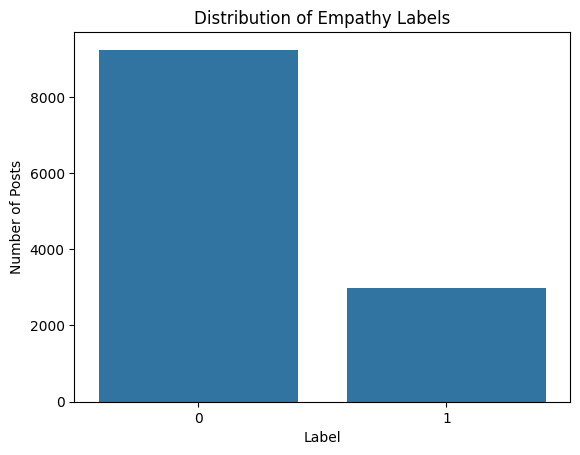

In [5]:
sns.countplot(data=df, x='combined_empathy')
plt.title("Distribution of Empathy Labels")
plt.xlabel("Label")
plt.ylabel("Number of Posts")
plt.show()

We observe that the dataset is **strongly imbalanced**, with significantly more posts labeled as *not containing empathy*.

This imbalance must be considered when training models.

## 5. Conversation Analysis <a name = "ca"></a>

Posts are grouped into conversations where users interact with each other.

We analyze the number of posts per conversation.

In [7]:
posts_per_conv = df.groupby("conv_id").size()
posts_per_conv.describe()

count    1730.000000
mean        7.058960
std         5.123122
min         1.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        23.000000
dtype: float64

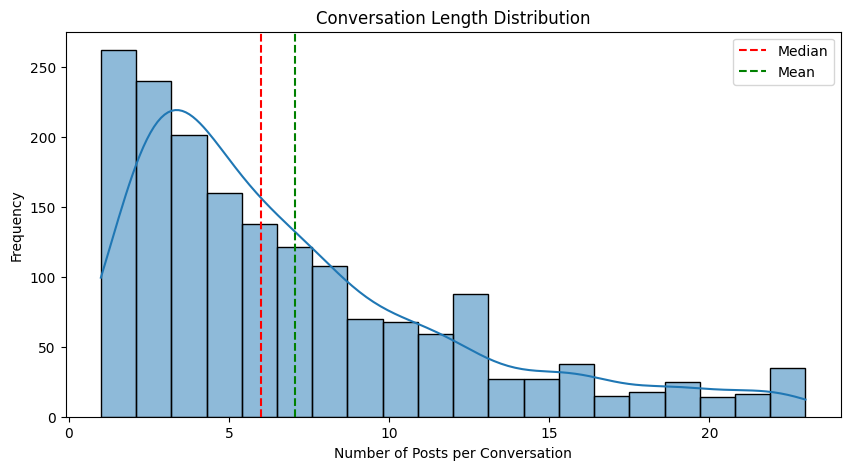

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(posts_per_conv, bins=20, kde=True)
plt.axvline(posts_per_conv.median(), color='red', linestyle='--', label='Median')
plt.axvline(posts_per_conv.mean(), color='green', linestyle='--', label='Mean')
plt.title("Conversation Length Distribution")
plt.xlabel("Number of Posts per Conversation")
plt.ylabel("Frequency")

plt.legend()
plt.show()

This graph reflects the preprocessing applied to the dataset, following the methodology described in the original dataset paper [1].


> “However, the number of posts within each conversation varied widely, ranging from 1 (a post created by the initial author with no replies) to 7,740. To address this, we calculated the Interquartile Range (IQR) from the full distribution of posts per conversation across all forum conversations. Since the distribution was skewed toward shorter conversations, we set the acceptable bounds for the number of posts in a conversation to integers between 1 and 23, inclusive, in order to remove outlier conversations from the dataset. After filtering the conversations, we were left with 1,740 conversations and a total of 12,249 posts, including replies and quotes.”  


## 6. User Activity <a name = "ua"></a>

We now explore the participation of users in the dataset.

In [13]:
posts_per_user = df.groupby("user_id").size()
posts_per_user.describe()

count    2707.000000
mean        4.511267
std        11.979664
min         1.000000
25%         1.000000
50%         1.000000
75%         4.000000
max       257.000000
dtype: float64

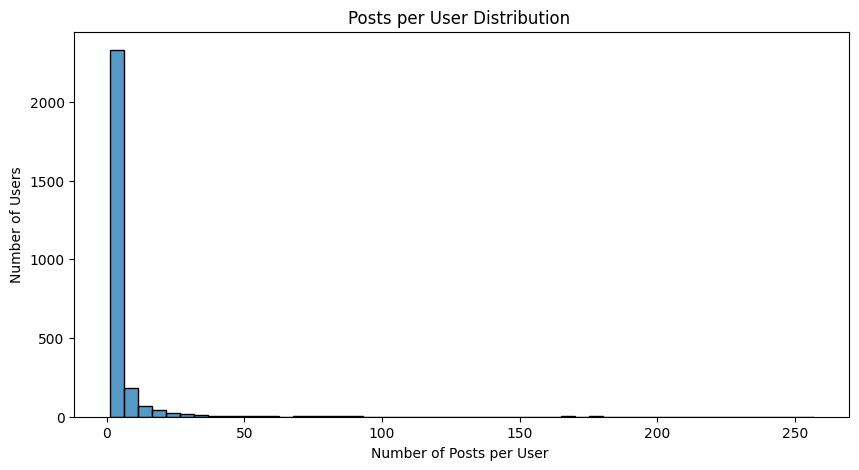

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(posts_per_user, bins=50)
  

plt.title("Posts per User Distribution ")
plt.xlabel("Number of Posts per User ")
plt.ylabel("Number of Users")

plt.show()

This table and graph confirm the pattern  described in the original dataset paper [1]: 

> In total, AcnEmpathize includes 2,527 unique users, excluding anonymous users who are assigned user IDs of 0. The number of posts made by users ranges from 1 to 257, with an average of 4.398 posts per user (median of 1.000 post and a standard deviation of 11.464 posts). Notably, six "super users" contributed 100 or more posts each.

So, some users contribute significantly more posts than others, suggesting the presence of **highly active community members**.

## 7. Text Length Analysis <a name = "tla"></a>

We examine how long the posts are.

In [10]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

In [11]:
df['text_length'].describe()

count    12212.000000
mean       132.766541
std        358.301049
min          1.000000
25%         34.000000
50%         80.000000
75%        163.000000
max      34208.000000
Name: text_length, dtype: float64

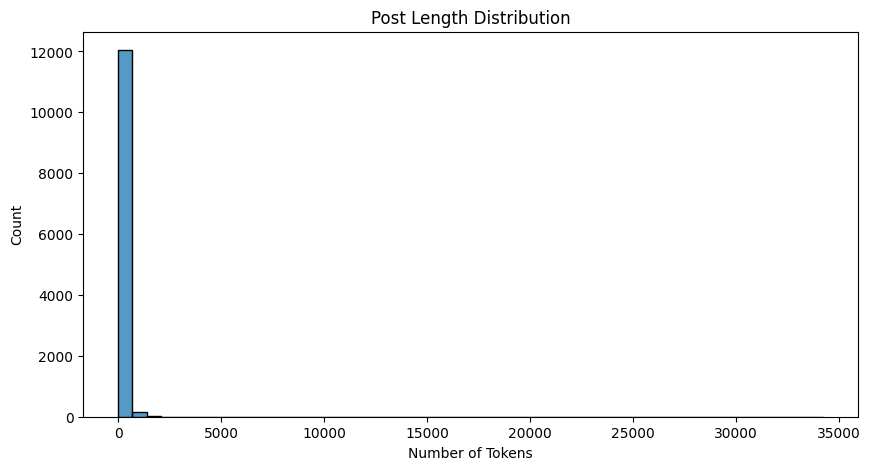

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Post Length Distribution")
plt.xlabel("Number of Tokens")
plt.show()

## 8. Post Length by Class <a name = "plc"></a>

We investigate whether empathetic posts tend to be longer.

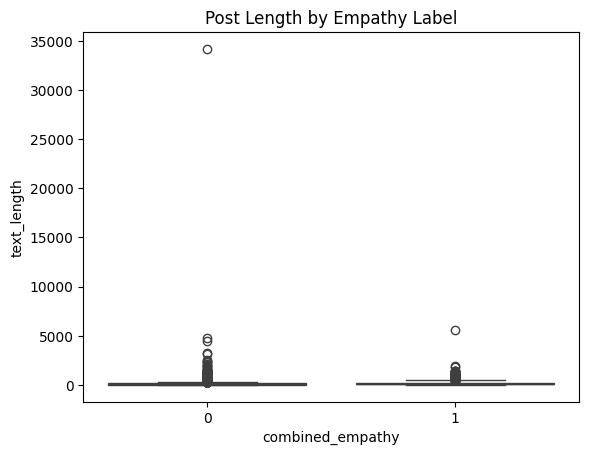

In [13]:
sns.boxplot(data=df, x='combined_empathy', y='text_length')
plt.title("Post Length by Empathy Label")
plt.show()

The behaviour seems the same for both empathic and non-empathic  posts.

## 9. Language patterns <a name = "lp"></a>

### 9.1 Tokenization of Posts <a name = "tp"></a>

To analyze language patterns in the dataset we first need to split the text into words (tokens).

This allows us to study:

• vocabulary size  
• word frequency  
• common linguistic expressions  
• differences between empathetic and non-empathetic posts

At this stage we only perform **minimal preprocessing** ( tokenized each post, removed punctuation and stopwords, performed case normalization, and lemmatized all tokens) to preserve as much linguistic information as possible.

In [14]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /Users/gjoli/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))

def preprocess(text):
    
    doc = nlp(text.lower())
    
    tokens = []
    
    for token in doc:
        
        # remove punctuation, stopwords, numbers
        if (
            token.text not in string.punctuation
            and token.text not in stop_words
            and token.is_alpha
        ):
            
            lemma = token.lemma_
            
            # remove contractions like "youre", "ill"
            if lemma not in ["youre", "ill"]:
                tokens.append(lemma)
    
    return tokens

df["tokens_clean"] = df["text"].apply(preprocess)

### 9.2 Vocabulary Size <a name = "vs"></a>

We compute the total vocabulary of the dataset.

Vocabulary size helps us understand:

• how diverse the language is  
• how large the feature space might become when using Bag-of-Words or TF-IDF representations  
• whether dimensionality reduction techniques may be necessary

In [17]:
all_tokens = [token for tokens in df["tokens_clean"] for token in tokens]

vocab = set(all_tokens)

print("Vocabulary size:", len(vocab))

Vocabulary size: 19109


### 9.3 Most Frequent Words <a name = "mfw"></a>





We examine the most common words in the dataset.

This helps us identify:

• dominant topics in the forum  
• common conversational language  
• whether emotional vocabulary appears frequently

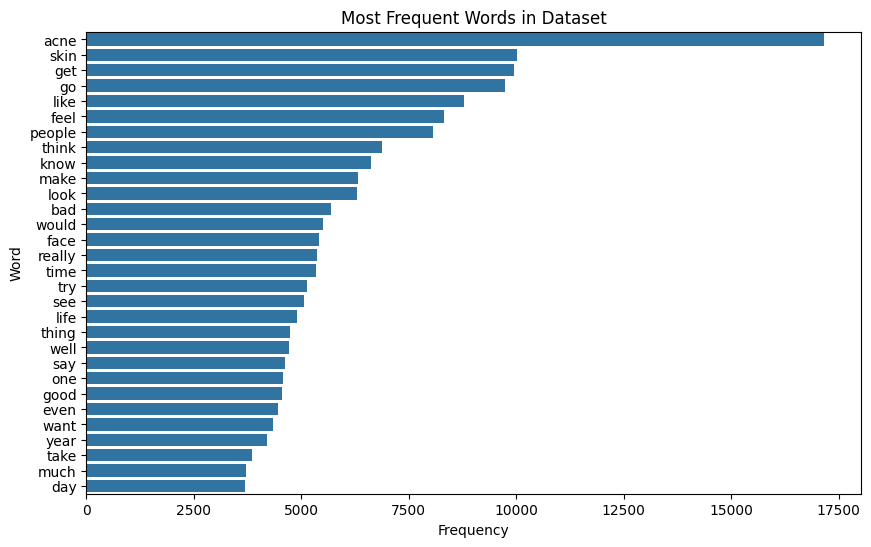

In [18]:
word_counts = Counter(all_tokens)

common_words = word_counts.most_common(30)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=words)
plt.title("Most Frequent Words in Dataset")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

High-frequency words typically include conversational terms such as "skin", or "acne".
These reflect the **personal and conversational nature of the discussions**.

### 9.4 Vocabulary Differences Between Classes <a name = "vdbc"></a>

One important question is whether empathetic posts use different words than non-empathetic ones.


The following analysis differs from a simple top-frequency comparison.

- A raw frequency plot highlights words that are common within each class, but in a domain-specific corpus such as AcnEmpathize, this tends to surface topic words like "acne" and "skin", which are frequent in both classes.

- To identify words that are truly characteristic of each label, we instead compute the **log-odds ratio with an informative Dirichlet prior**. This highlights words that are disproportionately associated with empathy or non-empathy rather than merely frequent overall.

In [19]:
# empathy = 1
emp_tokens = [
    token
    for tokens in df[df.combined_empathy == 1]["tokens_clean"]
    for token in tokens
]

# non-empathy = 0
non_tokens = [
    token
    for tokens in df[df.combined_empathy == 0]["tokens_clean"]
    for token in tokens
]

emp_counts = Counter(emp_tokens)
non_counts = Counter(non_tokens)

# global vocabulary
vocab = set(emp_counts.keys()).union(set(non_counts.keys()))

##### Log-Odds with Informative Dirichlet Prior

In [20]:
z_scores, sorted_scores = compute_log_odds(
    emp_tokens,
    non_tokens,
    alpha=0.01,
    min_freq=5
)

top_non, top_emp = get_top_k(sorted_scores, k=20)

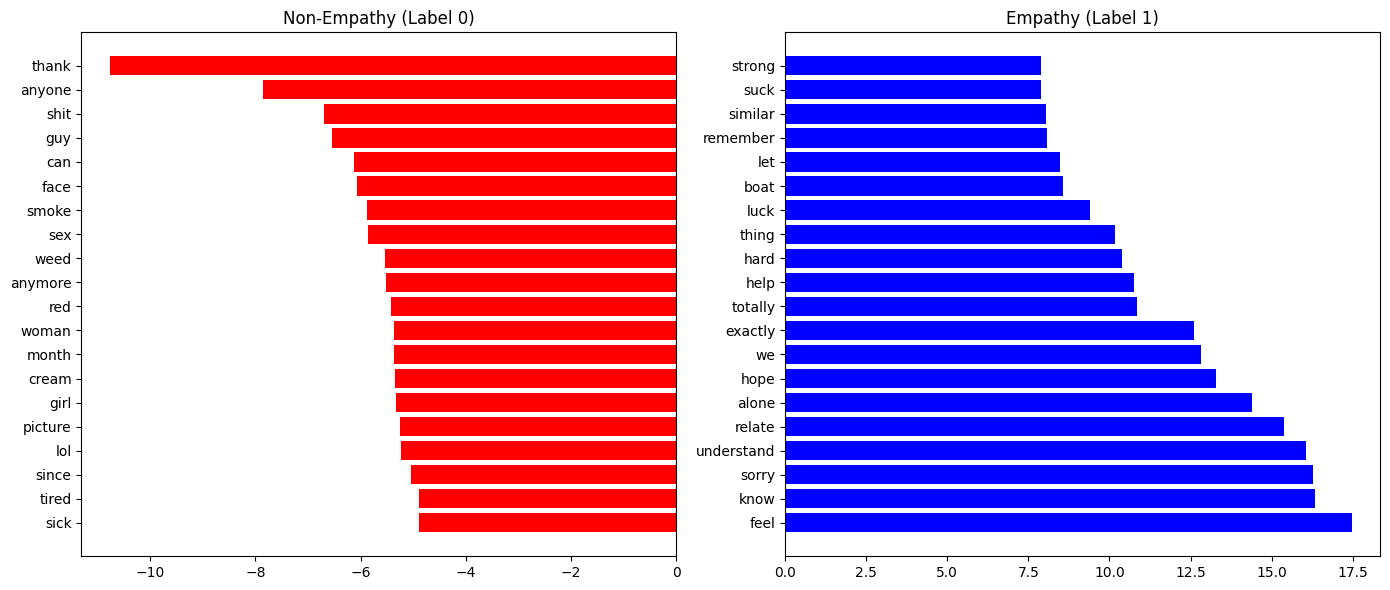

In [21]:

# unpack
words_non = [w[0] for w in top_non]
scores_non = [w[1] for w in top_non]

words_emp = [w[0] for w in top_emp]
scores_emp = [w[1] for w in top_emp]

plot_log_odds(top_non, top_emp, "Non-Empathy (Label 0)", "Empathy (Label 1)")

### 9.5 Bigram Analysis <a name = "ba"></a>

Empathy is often expressed through phrases rather than isolated words, such as: "I understand" , "I feel" , "I'm sorry"

To capture these patterns, we analyze bigrams (pairs of consecutive words) extracted from the cleaned tokens. This helps identify common empathy-related expressions.

In [ ]:
def get_bigrams(tokens):
    return list(ngrams(tokens, 2))

In [23]:

df["bigrams"] = df["tokens_clean"].apply(get_bigrams)

emp_bigrams = [
    bg for bgs in df[df.combined_empathy==1]["bigrams"] for bg in bgs
]

non_bigrams = [
    bg for bgs in df[df.combined_empathy==0]["bigrams"] for bg in bgs
]

z_bg, sorted_bg = compute_log_odds(
    emp_bigrams,
    non_bigrams,
    alpha=0.01,
    min_freq=5
)

top_non_bg, top_emp_bg = get_top_k(sorted_bg, k=15)

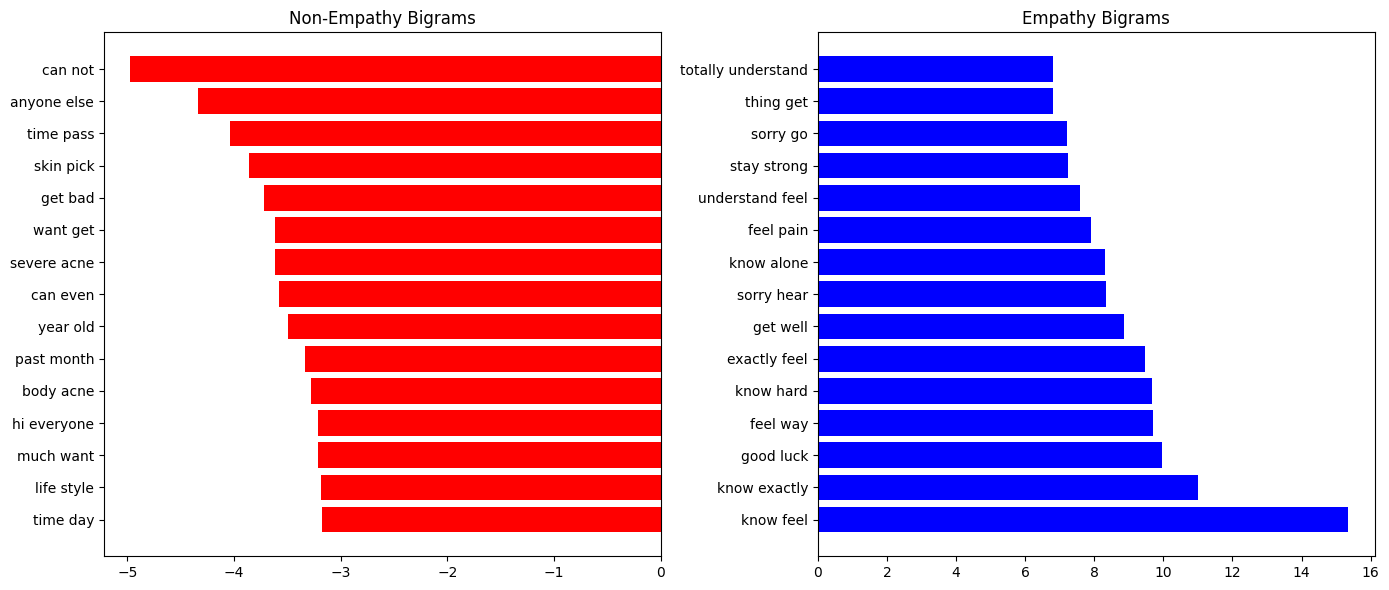

In [24]:
plot_log_odds(top_non_bg, top_emp_bg, "Non-Empathy Bigrams", "Empathy Bigrams")

### 9.6  Topic Modeling <a name = "tm"></a>

We apply **Latent Dirichlet Allocation (LDA)** to identify the main themes discussed in the forum.

Unlike previous steps, topic modeling focuses on uncovering latent semantic structure rather than discriminative features. We use the cleaned tokens to ensure consistent preprocessing.

In [29]:
# join tokens back into text
df["clean_text"] = df["tokens_clean"].apply(lambda x: " ".join(x))

vectorizer = CountVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])

In [30]:
lda = LatentDirichletAllocation(n_components=10, random_state=42)

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [34]:
n_words=10
words = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
        
        top_words = [words[i] for i in topic.argsort()[-n_words:][::-1]]
        
        print(f"\n Topic {idx}")
        print("   " + " | ".join(top_words))


 Topic 0
   life | good | thing | people | find | post | one | we | thank | make

 Topic 1
   acne | scar | get | girl | like | look | would | see | guy | go

 Topic 2
   skin | go | time | make | month | shit | get | would | social | start

 Topic 3
   accutane | acne | take | year | go | skin | get | try | work | treatment

 Topic 4
   skin | use | try | good | product | oil | water | help | also | make

 Topic 5
   acne | people | diet | cause | help | think | food | also | get | would

 Topic 6
   acne | face | get | go | bad | skin | start | month | pimple | like

 Topic 7
   people | acne | think | skin | like | feel | life | say | know | thing

 Topic 8
   feel | like | get | go | skin | know | acne | really | not | make

 Topic 9
   go | look | acne | like | would | get | school | face | see | make


The topic modeling results reveal several coherent themes present in the dataset, reflecting both the practical and emotional dimensions of acne-related discussions.

-   Topic 0 – General discussion / support
    - This topic includes words such as make, thank, people, good, life, suggesting general conversational exchanges and supportive interactions between users. It reflects the community aspect of the forum.

-   Topic 1 – Appearance and social perception
    - With words like guy, girl, look, scar, acne, this topic captures concerns about physical appearance and how acne affects attractiveness and social interactions.

-   Topic 2 – Social struggles over time
    - Words such as social, month, time, skin indicate ongoing difficulties and the temporal dimension of dealing with acne, often linked to social challenges.

-    Topic 3 – Medical treatment
    - This topic includes treatment, accutane, year, take, clearly representing discussions about clinical solutions and long-term treatment processes.

-   Topic 4 – Skincare routines and products
    - Words like product, oil, water, use, skin suggest practical advice and routines related to skincare.

-   Topic 5 – Diet and causes of acne
    - With food, diet, cause, this topic reflects discussions about lifestyle factors and possible causes of acne.

-    Topic 6 – Acne progression and symptoms
    - Words such as pimple, bad, face, month indicate descriptions of acne severity and progression over time.

-   Topic 7 – Emotional reflection
    - This topic includes feel, life, think, know, representing introspection and emotional expression, which is closely related to empathetic communication.

-    Topic 8 – General emotional language
    - Containing words like feel, know, like, this topic captures more generic emotional or conversational expressions that may appear across different contexts.

-    Topic 9 – Social environment (e.g., school)
    - With words such as school, face, look, this topic reflects specific social settings where acne impacts interactions and self-image.

---

#  EDA Conclusion <a name = "eda_c"></a>



The exploratory analysis of the AcnEmpathize dataset reveals that the task of empathy detection is inherently complex and influenced by multiple linguistic and contextual factors. The dataset is notably imbalanced, with non-empathetic posts significantly outnumbering empathetic ones, which has important implications for model evaluation and training.

- Lexical analysis shows that simple frequency-based methods primarily capture domain-specific vocabulary (e.g., "acne", "skin"), while discriminative approaches such as log-odds reveal that empathetic language is characterized by expressions of emotional alignment and support (e.g., "understand", "relate", "sorry"). This highlights the importance of focusing on class-discriminative features rather than general word frequency.

- Further analysis indicates that empathy is often conveyed through phrase-level patterns rather than isolated words, reinforcing the relevance of n-gram representations. Sentiment analysis suggests that empathy is associated with emotional expression, although polarity alone is insufficient to fully distinguish empathetic from non-empathetic posts.

- Topic modeling reveals that discussions in the dataset span technical (e.g., treatment, skincare), experiential (e.g., appearance, social interactions), and emotional dimensions. Notably, empathetic content is more closely associated with emotionally reflective topics, while technical discussions tend to be less empathetic.

Overall, these findings suggest that effective empathy detection requires a combination of lexical, semantic, and contextual features. In particular, representations that capture emotional language, phrase structure, and discriminative word usage are likely to be most informative for classification.

---

# References <a name = "r"></a>

[1] Lee, G., & Parde, N. (Year). *AcnEmpathize: A Dataset for Understanding Empathy in
Dermatology Conversations*. University of Illinois Chicago.